In [1]:
!pip install kaggle

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [2]:
!kaggle datasets download -d giripujar/hr-analytics

!unzip hr-analytics.zip

import pandas as pd
df = pd.read_csv('HR_comma_sep.csv')

display(df.head())

Dataset URL: https://www.kaggle.com/datasets/giripujar/hr-analytics
License(s): CC0-1.0
100% 111k/111k [00:00<00:00, 73.4MB/s]

Archive:  hr-analytics.zip
  inflating: HR_comma_sep.csv        


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [3]:
display(df.info())

display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


None

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


Distribution of Employee Retention (0=retained, 1=left):


,count
left,
0,11428
1,3571


,proportion
left,
0,76.191746
1,23.808254


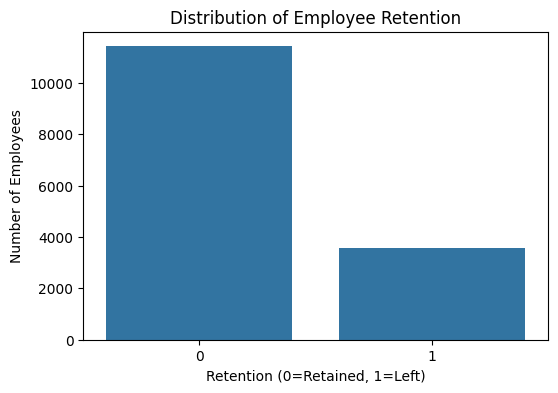

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

print('Distribution of Employee Retention (0=retained, 1=left):')
display(df['left'].value_counts())
display(df['left'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(x='left', data=df)
plt.title('Distribution of Employee Retention')
plt.xlabel('Retention (0=Retained, 1=Left)')
plt.ylabel('Number of Employees')
plt.show()

## Impact of Employee Salaries on Retention

Now, let's visualize how different salary levels affect employee retention. We will use bar charts to compare the retention rate (employees who left) across different salary categories.

Retention Rate by Salary Level:


left,0,1,Retention_Rate
salary,,,
high,1155,82,0.066289
low,5144,2172,0.296884
medium,5129,1317,0.204313


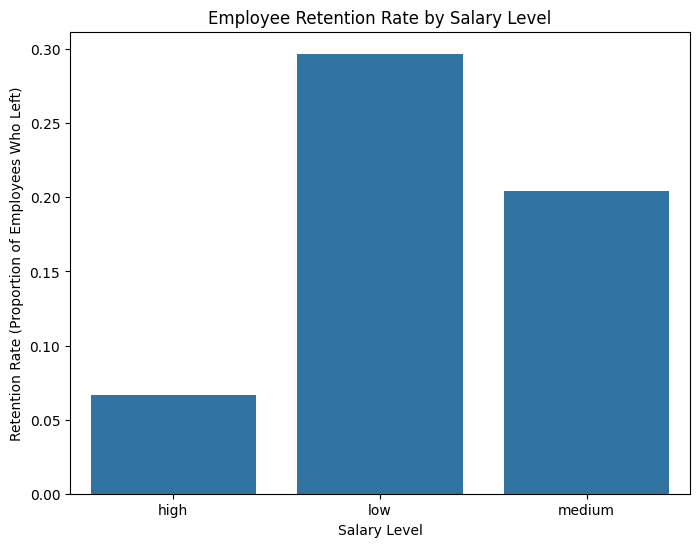

In [5]:
salary_retention = df.groupby(['salary', 'left']).size().unstack(fill_value=0)

salary_retention['Retention_Rate'] = salary_retention[1] / (salary_retention[0] + salary_retention[1])

print('Retention Rate by Salary Level:')
display(salary_retention)

plt.figure(figsize=(8, 6))
sns.barplot(x=salary_retention.index, y='Retention_Rate', data=salary_retention)
plt.title('Employee Retention Rate by Salary Level')
plt.xlabel('Salary Level')
plt.ylabel('Retention Rate (Proportion of Employees Who Left)')
plt.show()

Retention Rate by Department:


left,0,1,Retention_Rate
Department,,,
hr,524,215,0.290934
accounting,563,204,0.265971
technical,2023,697,0.256250
support,1674,555,0.248991
sales,3126,1014,0.244928
marketing,655,203,0.236597
IT,954,273,0.222494
product_mng,704,198,0.219512
RandD,666,121,0.153748


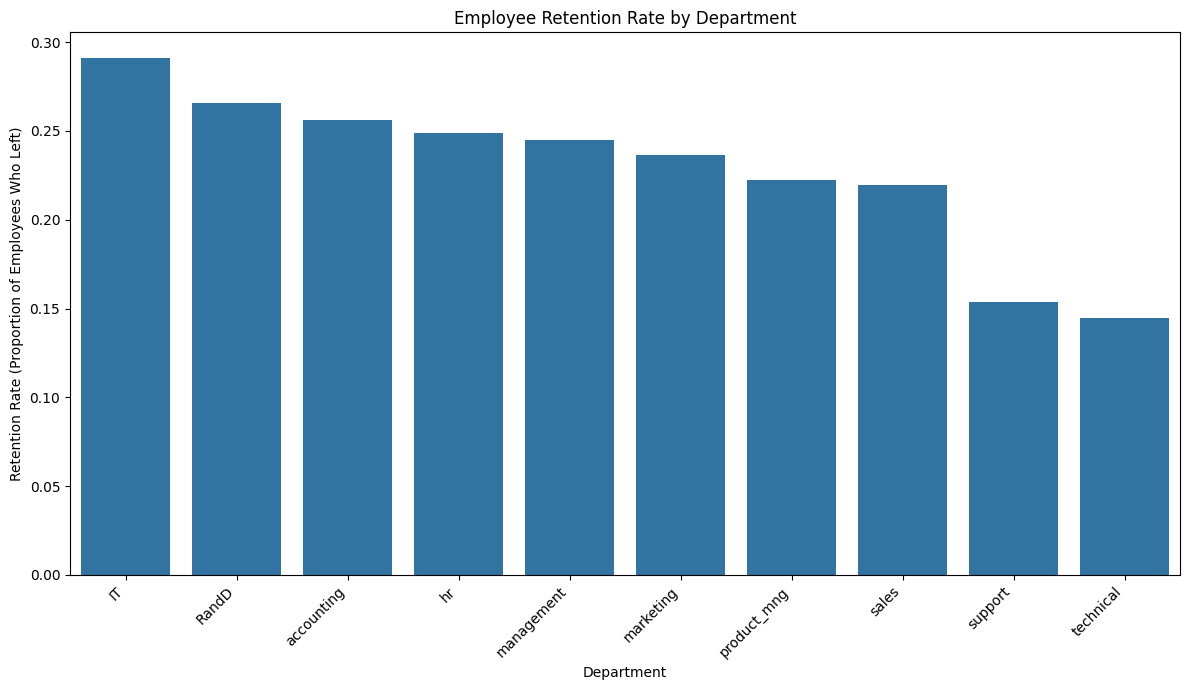

In [6]:
department_retention = df.groupby(['Department', 'left']).size().unstack(fill_value=0)

department_retention['Retention_Rate'] = department_retention[1] / (department_retention[0] + department_retention[1])

print('Retention Rate by Department:')
display(department_retention.sort_values('Retention_Rate', ascending=False))

plt.figure(figsize=(12, 7))
sns.barplot(x=department_retention.index, y='Retention_Rate', data=department_retention.sort_values('Retention_Rate', ascending=False))
plt.title('Employee Retention Rate by Department')
plt.xlabel('Department')
plt.ylabel('Retention Rate (Proportion of Employees Who Left)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

df_model = pd.get_dummies(df_model, columns=['Department', 'salary'], drop_first=True)

X = df_model.drop('left', axis=1)
y = df_model['left']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print('Shape of X_train:', X_train.shape)
print('Shape of X_test:', X_test.shape)
print('Shape of y_train:', y_train.shape)
print('Shape of y_test:', y_test.shape)

display(X.head())

Shape of X_train: (10499, 18)
Shape of X_test: (4500, 18)
Shape of y_train: (10499,)
Shape of y_test: (4500,)


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,0,False,False,False,False,False,False,True,False,False,True,False
1,0.80,0.86,5,262,6,0,0,False,False,False,False,False,False,True,False,False,False,True
2,0.11,0.88,7,272,4,0,0,False,False,False,False,False,False,True,False,False,False,True
3,0.72,0.87,5,223,5,0,0,False,False,False,False,False,False,True,False,False,True,False
4,0.37,0.52,2,159,3,0,0,False,False,False,False,False,False,True,False,False,True,False


In [8]:
model = LogisticRegression(max_iter=1000, solver='liblinear')

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

from sklearn.metrics import classification_report, confusion_matrix
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred),
                     columns=['Predicted Not Left', 'Predicted Left'],
                     index=['Actual Not Left', 'Actual Left']))

Model Accuracy: 0.7831

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.93      0.87      3428
           1       0.58      0.33      0.42      1072

    accuracy                           0.78      4500
   macro avg       0.70      0.63      0.64      4500
weighted avg       0.76      0.78      0.76      4500


Confusion Matrix:


,Predicted Not Left,Predicted Left
Actual Not Left,3173,255
Actual Left,721,351
